In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve

# Constants
EPS = 1e-15
print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [32]:
base = '../../data/'
train = pd.read_csv(base + 'train.csv')
test  = pd.read_csv(base + 'test.csv')

missing_cols = ['followup_days','hemoglobin_g_dl','creatinine_mg_dl', 'sodium_mmol_l','heart_rate_bpm','systolic_bp_mmhg']
num_cols = ['age', 'socioeconomic_index', 'prior_admissions_12m', 'comorbidity_count', 'length_of_stay_days', 
            'medication_count', 'missed_appointments_12m', 'followup_days', 'hemoglobin_g_dl', 'creatinine_mg_dl', 
            'sodium_mmol_l', 'heart_rate_bpm', 'systolic_bp_mmhg', 'n_missing'] + [c + '_flag' for c in missing_cols]
cat_cols = ['sex', 'rurality', 'hospital_type', 'region', 'discharge_disposition', 'care_pathway']

for df in [train, test]:
    df['n_missing'] = df[missing_cols].isna().sum(axis=1)
    for c in missing_cols: 
        df[c + '_flag'] = df[c].isna().astype(int)
    df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 70, 120], labels=['<30', '30-50', '50-70', '70+'])

y = train['readmitted_30d']
X = train.drop(columns=['patient_id', 'readmitted_30d'])
print(f"✅ Data loaded and engineered. Train shape: {X.shape}")

✅ Data loaded and engineered. Train shape: (7000, 31)


In [33]:
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')), 
                     ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', n_jobs=-1, random_state=42)
model = Pipeline([('pre', preprocessor), ('clf', clf)])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

for tr_idx, val_idx in skf.split(X, y):
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_preds[val_idx] = model.predict_proba(X.iloc[val_idx])[:, 1]

oof_preds = np.clip(oof_preds, EPS, 1 - EPS)
print(f"✅ LR OOF Log Loss: {log_loss(y, oof_preds):.5f} | AUC: {roc_auc_score(y, oof_preds):.5f}")

✅ LR OOF Log Loss: 0.35261 | AUC: 0.68529


In [34]:
def slice_skill_score(col):
    rows = []
    for lev in train[col].dropna().unique():
        mask = train[col] == lev
        yt, pp_lr = y[mask], oof_preds[mask.values]
        
        p_const = yt.mean() 
        ll_const = log_loss(yt, np.full(len(yt), p_const), labels=[0,1])
        ll_lr = log_loss(yt, np.clip(pp_lr, EPS, 1-EPS), labels=[0,1])
        skill = ll_const - ll_lr 
        
        rows.append({
            'Group': lev, 'N': int(mask.sum()), 'Base_Rate': f"{p_const:.1%}",
            'Floor_LL': ll_const, 'LR_LL': ll_lr, 'Skill (Δ)': skill
        })
    return pd.DataFrame(rows).sort_values('Skill (Δ)', ascending=False)

print("--- SUBGROUP SKILL SCORES (Value Added by Model vs Constant Baseline) ---")
for col in ['rurality', 'region', 'hospital_type', 'age_group']:
    print(f"\n[{col.upper()}]")
    print(slice_skill_score(col)[['Group', 'N', 'Base_Rate', 'Floor_LL', 'LR_LL', 'Skill (Δ)']].to_string(index=False))

--- SUBGROUP SKILL SCORES (Value Added by Model vs Constant Baseline) ---

[RURALITY]
     Group    N Base_Rate  Floor_LL    LR_LL  Skill (Δ)
     Rural 1243     15.6%  0.433102 0.401465   0.031637
Semi-urban 1870     10.9%  0.344610 0.316070   0.028540
     Urban 3887     12.4%  0.375328 0.354572   0.020757

[REGION]
     Group    N Base_Rate  Floor_LL    LR_LL  Skill (Δ)
   Central 1529     12.9%  0.384180 0.349491   0.034689
North-East 1326     11.5%  0.356088 0.327736   0.028352
     South 1554     13.4%  0.394837 0.366485   0.028352
      West 2591     12.5%  0.376112 0.358867   0.017245

[HOSPITAL_TYPE]
   Group    N Base_Rate  Floor_LL    LR_LL  Skill (Δ)
District 1285     12.4%  0.374302 0.339745   0.034557
 General 2623     12.2%  0.370886 0.344195   0.026691
Teaching 3092     13.0%  0.386411 0.365102   0.021309

[AGE_GROUP]
Group    N Base_Rate  Floor_LL    LR_LL  Skill (Δ)
  70+ 1477     22.3%  0.530365 0.502337   0.028028
50-70 3150     12.1%  0.368188 0.355810   0.012378
3

In [35]:
ent = -oof_preds*np.log(oof_preds) - (1-oof_preds)*np.log(1-oof_preds)
cutoff = np.quantile(ent, 0.90)
keep_mask = ent <= cutoff
ref_mask = ~keep_mask

ll_all = log_loss(y, oof_preds)
ll_keep_ent = log_loss(y[keep_mask], oof_preds[keep_mask])

rng = np.random.default_rng(42)
keep_rand = rng.random(len(y)) <= 0.90
ll_keep_rand = log_loss(y[keep_rand], oof_preds[keep_rand])

total_events = y.sum()
referred_events = y[ref_mask].sum()

print("--- ABSTENTION CONTROL TEST (Top 10% Entropy vs Random 10%) ---")
print(f"LogLoss (All 100%):          {ll_all:.5f}")
print(f"LogLoss (Entropy Ref 10%):   {ll_keep_ent:.5f}  (Improvement: {ll_all - ll_keep_ent:.5f})")
print(f"LogLoss (Random Ref 10%):    {ll_keep_rand:.5f}  (Improvement: {ll_all - ll_keep_rand:.5f})")
print(f"\n--- CLINICAL IMPACT OF REFERRAL ---")
print(f"The most uncertain 10% of patients contains {referred_events} out of {total_events} total readmissions ({referred_events/total_events*100:.1f}%).")

--- ABSTENTION CONTROL TEST (Top 10% Entropy vs Random 10%) ---
LogLoss (All 100%):          0.35261
LogLoss (Entropy Ref 10%):   0.32406  (Improvement: 0.02855)
LogLoss (Random Ref 10%):    0.35579  (Improvement: -0.00318)

--- CLINICAL IMPACT OF REFERRAL ---
The most uncertain 10% of patients contains 222 out of 881 total readmissions (25.2%).


In [36]:
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
scores_with, scores_without = [], []

cat_cols_no_cp = [c for c in cat_cols if c != 'care_pathway']
preprocessor_no_cp = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols_no_cp)])
model_without = Pipeline([('pre', preprocessor_no_cp), ('clf', LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', n_jobs=-1, random_state=42))])

print("Running Repeated CV (15 folds)... this may take a minute.")
for tr_idx, val_idx in rskf.split(X, y):
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    scores_with.append(log_loss(y.iloc[val_idx], np.clip(model.predict_proba(X.iloc[val_idx])[:, 1], EPS, 1-EPS)))
    
    model_without.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    scores_without.append(log_loss(y.iloc[val_idx], np.clip(model_without.predict_proba(X.iloc[val_idx])[:, 1], EPS, 1-EPS)))

diff = np.array(scores_without) - np.array(scores_with)
print(f"\n--- REPEATED CV (15 folds): care_pathway SENSITIVITY ---")
print(f"WITH care_pathway    LL: {np.mean(scores_with):.5f} ± {np.std(scores_with):.5f}")
print(f"WITHOUT care_pathway LL: {np.mean(scores_without):.5f} ± {np.std(scores_without):.5f}")
print(f"Mean Difference (Without - With): {np.mean(diff):.5f} ± {np.std(diff):.5f}")

Running Repeated CV (15 folds)... this may take a minute.

--- REPEATED CV (15 folds): care_pathway SENSITIVITY ---
WITH care_pathway    LL: 0.35245 ± 0.00681
WITHOUT care_pathway LL: 0.35310 ± 0.00668
Mean Difference (Without - With): 0.00065 ± 0.00077


In [37]:
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
scores_with, scores_without = [], []

cat_cols_no_cp = [c for c in cat_cols if c != 'care_pathway']
preprocessor_no_cp = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols_no_cp)])
model_without = Pipeline([('pre', preprocessor_no_cp), ('clf', LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', n_jobs=-1, random_state=42))])

print("Running Repeated CV (15 folds)... this may take a minute.")
for tr_idx, val_idx in rskf.split(X, y):
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    scores_with.append(log_loss(y.iloc[val_idx], np.clip(model.predict_proba(X.iloc[val_idx])[:, 1], EPS, 1-EPS)))
    
    model_without.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    scores_without.append(log_loss(y.iloc[val_idx], np.clip(model_without.predict_proba(X.iloc[val_idx])[:, 1], EPS, 1-EPS)))

diff = np.array(scores_without) - np.array(scores_with)
print(f"\n--- REPEATED CV (15 folds): care_pathway SENSITIVITY ---")
print(f"WITH care_pathway    LL: {np.mean(scores_with):.5f} ± {np.std(scores_with):.5f}")
print(f"WITHOUT care_pathway LL: {np.mean(scores_without):.5f} ± {np.std(scores_without):.5f}")
print(f"Mean Difference (Without - With): {np.mean(diff):.5f} ± {np.std(diff):.5f}")

Running Repeated CV (15 folds)... this may take a minute.

--- REPEATED CV (15 folds): care_pathway SENSITIVITY ---
WITH care_pathway    LL: 0.35245 ± 0.00681
WITHOUT care_pathway LL: 0.35310 ± 0.00668
Mean Difference (Without - With): 0.00065 ± 0.00077


In [38]:
ll_normal, ll_stressed = [], []

for tr_idx, val_idx in skf.split(X, y):
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    model.fit(X_tr, y_tr)
    ll_normal.append(log_loss(y_val, np.clip(model.predict_proba(X_val)[:, 1], EPS, 1-EPS)))
    
    # Stress test: artificially mask 20% MORE lab values in the validation set
    X_val_stressed = X_val.copy()
    for c in missing_cols:
        drop_mask = rng.random(len(X_val_stressed)) < 0.20
        X_val_stressed.loc[drop_mask, c] = np.nan
        X_val_stressed[c + '_flag'] = X_val_stressed[c].isna().astype(int)
    X_val_stressed['n_missing'] = X_val_stressed[missing_cols].isna().sum(axis=1)
    
    ll_stressed.append(log_loss(y_val, np.clip(model.predict_proba(X_val_stressed)[:, 1], EPS, 1-EPS)))

print(f"--- Q1b: MASKING STRESS TEST (+20% artificial missingness) ---")
print(f"Normal CV LogLoss:   {np.mean(ll_normal):.5f}")
print(f"Stressed CV LogLoss: {np.mean(ll_stressed):.5f}")
print(f"Degradation:         +{np.mean(ll_stressed) - np.mean(ll_normal):.5f}")

--- Q1b: MASKING STRESS TEST (+20% artificial missingness) ---
Normal CV LogLoss:   0.35261
Stressed CV LogLoss: 0.35340
Degradation:         +0.00078


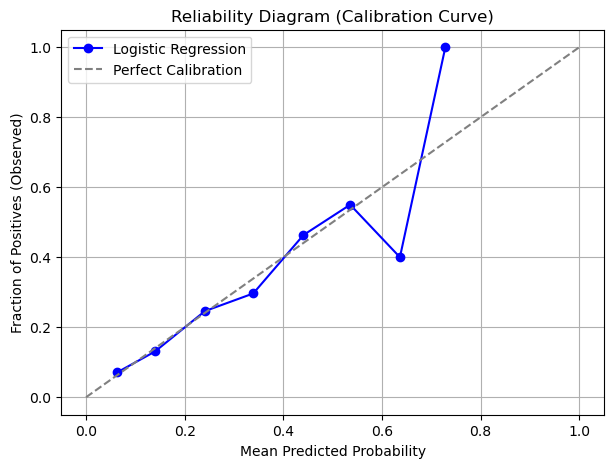


--- TOP 10 MOST INFLUENTIAL PREDICTORS (Odds Ratios) ---
                   Feature  Odds_Ratio  Distance_from_1
                       age    1.580955         0.580955
      prior_admissions_12m    1.391382         0.391382
discharge_disposition_Home    0.684799         0.315201
                sex_Female    0.705412         0.294588
       rurality_Semi-urban    0.708707         0.291293
                  sex_Male    0.723743         0.276257
           care_pathway_P1    0.750568         0.249432
    hospital_type_District    0.756146         0.243854
         comorbidity_count    1.241478         0.241478
           care_pathway_P2    0.762189         0.237811

*(Odds Ratio > 1 increases risk; < 1 decreases risk. E.g., 1.5 means 50% higher odds per unit increase)*


In [39]:
# 1. Reliability Diagram (Calibration Curve)
prob_true, prob_pred = calibration_curve(y, oof_preds, n_bins=10, strategy='uniform')
plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Observed)')
plt.title('Reliability Diagram (Calibration Curve)')
plt.legend()
plt.grid(True)
plt.show()

# 2. LR Coefficients (Odds Ratios)
model.fit(X, y) # Fit on full data for final interpretation
cat_encoder = model.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
cat_names = cat_encoder.get_feature_names_out(cat_cols)
all_names = np.concatenate([num_cols, cat_names])

coefs = model.named_steps['clf'].coef_[0]
odds_ratios = np.exp(coefs)

coef_df = pd.DataFrame({'Feature': all_names, 'Odds_Ratio': odds_ratios})
coef_df['Distance_from_1'] = abs(coef_df['Odds_Ratio'] - 1)
coef_df = coef_df.sort_values('Distance_from_1', ascending=False)

print("\n--- TOP 10 MOST INFLUENTIAL PREDICTORS (Odds Ratios) ---")
print(coef_df.head(10).to_string(index=False))
print("\n*(Odds Ratio > 1 increases risk; < 1 decreases risk. E.g., 1.5 means 50% higher odds per unit increase)*")

In [ ]:
import numpy as np
import pandas as pd
import os

# 1. Fit the final Logistic Regression model on the FULL training set
# (Assuming 'model', 'X', 'y', 'num_cols', and 'cat_cols' are already in memory from previous cells)
print("Training final Logistic Regression on full dataset...")
model.fit(X, y)

# 2. Predict probabilities on the test set
test_features = test[num_cols + cat_cols]
p_test_lr = model.predict_proba(test_features)[:, 1]

# 3. Clip probabilities strictly between 0 and 1 to avoid infinite Log Loss penalties
p_test_lr = np.clip(p_test_lr, 1e-6, 1 - 1e-6)

# 4. Create the submission dataframe
sub_lr = pd.DataFrame({
    'patient_id': test['patient_id'],
    'readmitted_30d': p_test_lr
})

# 5. Strict Sanity Checks before saving
assert len(sub_lr) == len(test), "❌ Row count mismatch!"
assert (sub_lr['patient_id'].values == test['patient_id'].values).all(), "❌ ID order mismatch!"
assert ((sub_lr['readmitted_30d'] > 0) & (sub_lr['readmitted_30d'] < 1)).all(), "❌ Probabilities out of bounds!"

# 6. Save to CSV in Kaggle's output directory
output_dir = '../submissions/'  # Change this to '/kaggle/working/' if running on Kaggle
output_path = os.path.join(output_dir, 'submission_02_logreg.csv')
sub_lr.to_csv(output_path, index=False)

print("="*50)
print("✅ submission_02_logreg.csv saved successfully!")
print(f"Mean predicted probability: {p_test_lr.mean():.5f}")
print(f"Train baseline prevalence:  {y.mean():.5f}")
print("="*50)

Training final Logistic Regression on full dataset...
✅ submission_02_logreg.csv saved successfully!
Mean predicted probability: 0.13747
Train baseline prevalence:  0.12586


Exception ignored in: <function ResourceTracker.__del__ at 0x7f977d18e660>
Traceback (most recent call last):
  File "/home/teshan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/teshan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/teshan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f19a3396660>
Traceback (most recent call last):
  File "/home/teshan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/teshan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/teshan/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__